## Imports and configuration

In [1]:
import os, json, warnings, random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import tensorflow as tf

warnings.filterwarnings("ignore")
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

NOTEBOOK_ROOT = Path(r"E:\programming languages\DJANGO PROJECT\SmartAgriVision\SmartAgriVision\AgriVision\AI\notebooks")

PREPROCESSED_ROOT = NOTEBOOK_ROOT / "Preprocessed_Dataset"
METADATA_PATH = PREPROCESSED_ROOT / "metadata" / "image_metadata_preprocessed.csv"

CNN_DATASET_ROOT = NOTEBOOK_ROOT / "CNN_Classification_Dataset"
CNN_MODEL_ROOT = NOTEBOOK_ROOT / "CNN_Models"

YOLO_MODEL_ROOT = NOTEBOOK_ROOT / "YOLO_Models"
YOLO_BEST = YOLO_MODEL_ROOT / "classification_runs" / "smartagrivision_yolo_classification_cpu" / "weights" / "best.pt"

OUTPUT_ROOT = NOTEBOOK_ROOT / "Final_Testing_Results"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

print("Notebook root:", NOTEBOOK_ROOT)
print("Metadata:", METADATA_PATH.exists())
print("CNN dataset:", CNN_DATASET_ROOT.exists())
print("CNN models:", CNN_MODEL_ROOT.exists())
print("YOLO best:", YOLO_BEST.exists())
print("Output:", OUTPUT_ROOT)

Notebook root: E:\programming languages\DJANGO PROJECT\SmartAgriVision\SmartAgriVision\AgriVision\AI\notebooks
Metadata: True
CNN dataset: True
CNN models: True
YOLO best: True
Output: E:\programming languages\DJANGO PROJECT\SmartAgriVision\SmartAgriVision\AgriVision\AI\notebooks\Final_Testing_Results


## Device check

In [2]:
print("DEVICE CHECK")
gpus = tf.config.list_physical_devices("GPU")
print("GPU Available:", bool(gpus))
print("Device:", "GPU" if gpus else "CPU")

DEVICE CHECK
GPU Available: False
Device: CPU


## Load and validate metadata

In [3]:
if not METADATA_PATH.exists():
    raise FileNotFoundError(f"Metadata not found: {METADATA_PATH}")

metadata = pd.read_csv(METADATA_PATH)
required = ["Dataset","Split","Class","Image_Path","Filename","Label","Encoded_Label","Processed_Split"]
missing_cols = [c for c in required if c not in metadata.columns]
if missing_cols:
    raise ValueError(f"Missing metadata columns: {missing_cols}")

metadata["Class"] = metadata["Class"].astype(str).str.strip()
metadata["Processed_Split"] = metadata["Processed_Split"].astype(str).str.strip().str.lower()

class_names = sorted(metadata["Class"].dropna().unique().tolist())
NUM_CLASSES = len(class_names)

print("Metadata rows:", len(metadata))
print("Classes:", NUM_CLASSES)
print("Missing values:")
display(metadata[required].isna().sum())

Metadata rows: 294695
Classes: 82
Missing values:


Dataset            0
Split              0
Class              0
Image_Path         0
Filename           0
Label              0
Encoded_Label      0
Processed_Split    0
dtype: int64

## Resolve test image paths

In [4]:
IMAGE_EXTENSIONS = {".jpg",".jpeg",".png",".bmp",".webp"}

def resolve_path(value):
    if pd.isna(value):
        return None
    p = Path(str(value))
    candidates = [p]
    if not p.is_absolute():
        candidates.append(NOTEBOOK_ROOT / p)
    for c in candidates:
        if c.exists() and c.is_file():
            return c
    return None

test_meta = metadata[metadata["Processed_Split"].isin(["test","testing"])].copy()
test_meta["Resolved_Image_Path"] = test_meta["Image_Path"].map(resolve_path)

resolved = int(test_meta["Resolved_Image_Path"].notna().sum())
missing = int(test_meta["Resolved_Image_Path"].isna().sum())

print("TEST IMAGE PATH RESOLUTION")
print("Test records:", len(test_meta))
print("Resolved:", resolved)
print("Missing:", missing)

if resolved == 0:
    raise RuntimeError("No test images could be resolved. Fix metadata/image paths before final testing.")

TEST IMAGE PATH RESOLUTION
Test records: 3252
Resolved: 3252
Missing: 0


## Check CNN test folder

In [5]:
split_dirs = {
    "train": CNN_DATASET_ROOT / "train",
    "val": CNN_DATASET_ROOT / "val",
    "test": CNN_DATASET_ROOT / "test",
}

rows = []
for split, root in split_dirs.items():
    classes = [p for p in root.iterdir() if p.is_dir()] if root.exists() else []
    images = sum(
        1 for p in root.rglob("*")
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    ) if root.exists() else 0
    rows.append({"Split": split, "Class_Folders": len(classes), "Images": images,
                 "Ready": len(classes) > 0 and images > 0})
folder_check = pd.DataFrame(rows)
display(folder_check)

CNN_FOLDER_READY = bool(folder_check["Ready"].all())
print("CNN folder dataset ready:", CNN_FOLDER_READY)

,Split,Class_Folders,Images,Ready
0,train,82,90482,True
1,val,54,22468,True
2,test,43,5157,True


CNN folder dataset ready: True


## Locate CNN model

In [6]:
cnn_candidates = [
    CNN_MODEL_ROOT / "best_cnn_model.keras",
    CNN_MODEL_ROOT / "final_cnn_model.keras",
    CNN_MODEL_ROOT / "best_cnn_model.h5",
    CNN_MODEL_ROOT / "final_cnn_model.h5",
]
cnn_model_path = next((p for p in cnn_candidates if p.exists()), None)

print("CNN model:", cnn_model_path)
print("Exists:", cnn_model_path is not None)

cnn_model = None
if cnn_model_path:
    cnn_model = tf.keras.models.load_model(cnn_model_path)
    print("CNN model loaded.")
    print("Output shape:", cnn_model.output_shape)

CNN model: E:\programming languages\DJANGO PROJECT\SmartAgriVision\SmartAgriVision\AgriVision\AI\notebooks\CNN_Models\best_cnn_model.keras
Exists: True
CNN model loaded.
Output shape: (None, 82)


## CNN final test evaluation from resolved metadata

In [7]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

cnn_results = None
if cnn_model is None:
    print("CNN model unavailable; CNN final testing skipped.")
else:
    target_size = cnn_model.input_shape[1:3]
    channels = cnn_model.input_shape[-1] or 3

    def load_one_image(path):
        img = Image.open(path).convert("RGB")
        img = img.resize((int(target_size[1]), int(target_size[0])))
        arr = np.asarray(img, dtype=np.float32) / 255.0
        if channels == 1:
            arr = np.mean(arr, axis=2, keepdims=True)
        return arr

    valid_test = test_meta[test_meta["Resolved_Image_Path"].notna()].copy()
    label_to_idx = {c:i for i,c in enumerate(class_names)}

    X = np.stack([load_one_image(p) for p in valid_test["Resolved_Image_Path"]])
    y_true = valid_test["Class"].map(label_to_idx).to_numpy()

    probs = cnn_model.predict(X, batch_size=32, verbose=1)
    y_pred = np.argmax(probs, axis=1)
    confidence = np.max(probs, axis=1)

    cnn_results = valid_test[["Class","Filename","Resolved_Image_Path"]].copy()
    cnn_results["Actual_Index"] = y_true
    cnn_results["Predicted_Class"] = [class_names[i] for i in y_pred]
    cnn_results["Confidence"] = confidence
    cnn_results["Correct"] = y_true == y_pred

    cnn_metrics = {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision_macro": float(precision_score(y_true, y_pred, average="macro", zero_division=0)),
        "recall_macro": float(recall_score(y_true, y_pred, average="macro", zero_division=0)),
        "f1_macro": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
    }

    print("CNN FINAL TEST METRICS")
    for k,v in cnn_metrics.items():
        print(f"{k}: {v:.4f}")

102/102 ━━━━━━━━━━━━━━━━━━━━ 16s 149ms/step
CNN FINAL TEST METRICS
accuracy: 0.7355
precision_macro: 0.2583
recall_macro: 0.2508
f1_macro: 0.2335


## CNN classification report

In [8]:
if cnn_results is not None:
    report_dict = classification_report(
        cnn_results["Actual_Index"],
        cnn_results["Predicted_Class"].map(label_to_idx),
        labels=list(range(NUM_CLASSES)),
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )
    cnn_report = pd.DataFrame(report_dict).T
    display(cnn_report.head())
    cnn_report.to_csv(OUTPUT_ROOT / "cnn_classification_report.csv")

,precision,recall,f1-score,support
Apple_Scab_Leaf,0.0,0.0,0.0,10.0
Apple___Apple_scab,0.0,0.0,0.0,0.0
Apple___Black_rot,0.0,0.0,0.0,0.0
Apple___Cedar_apple_rust,0.0,0.0,0.0,0.0
Apple___healthy,0.0,0.0,0.0,0.0


## CNN confusion matrix

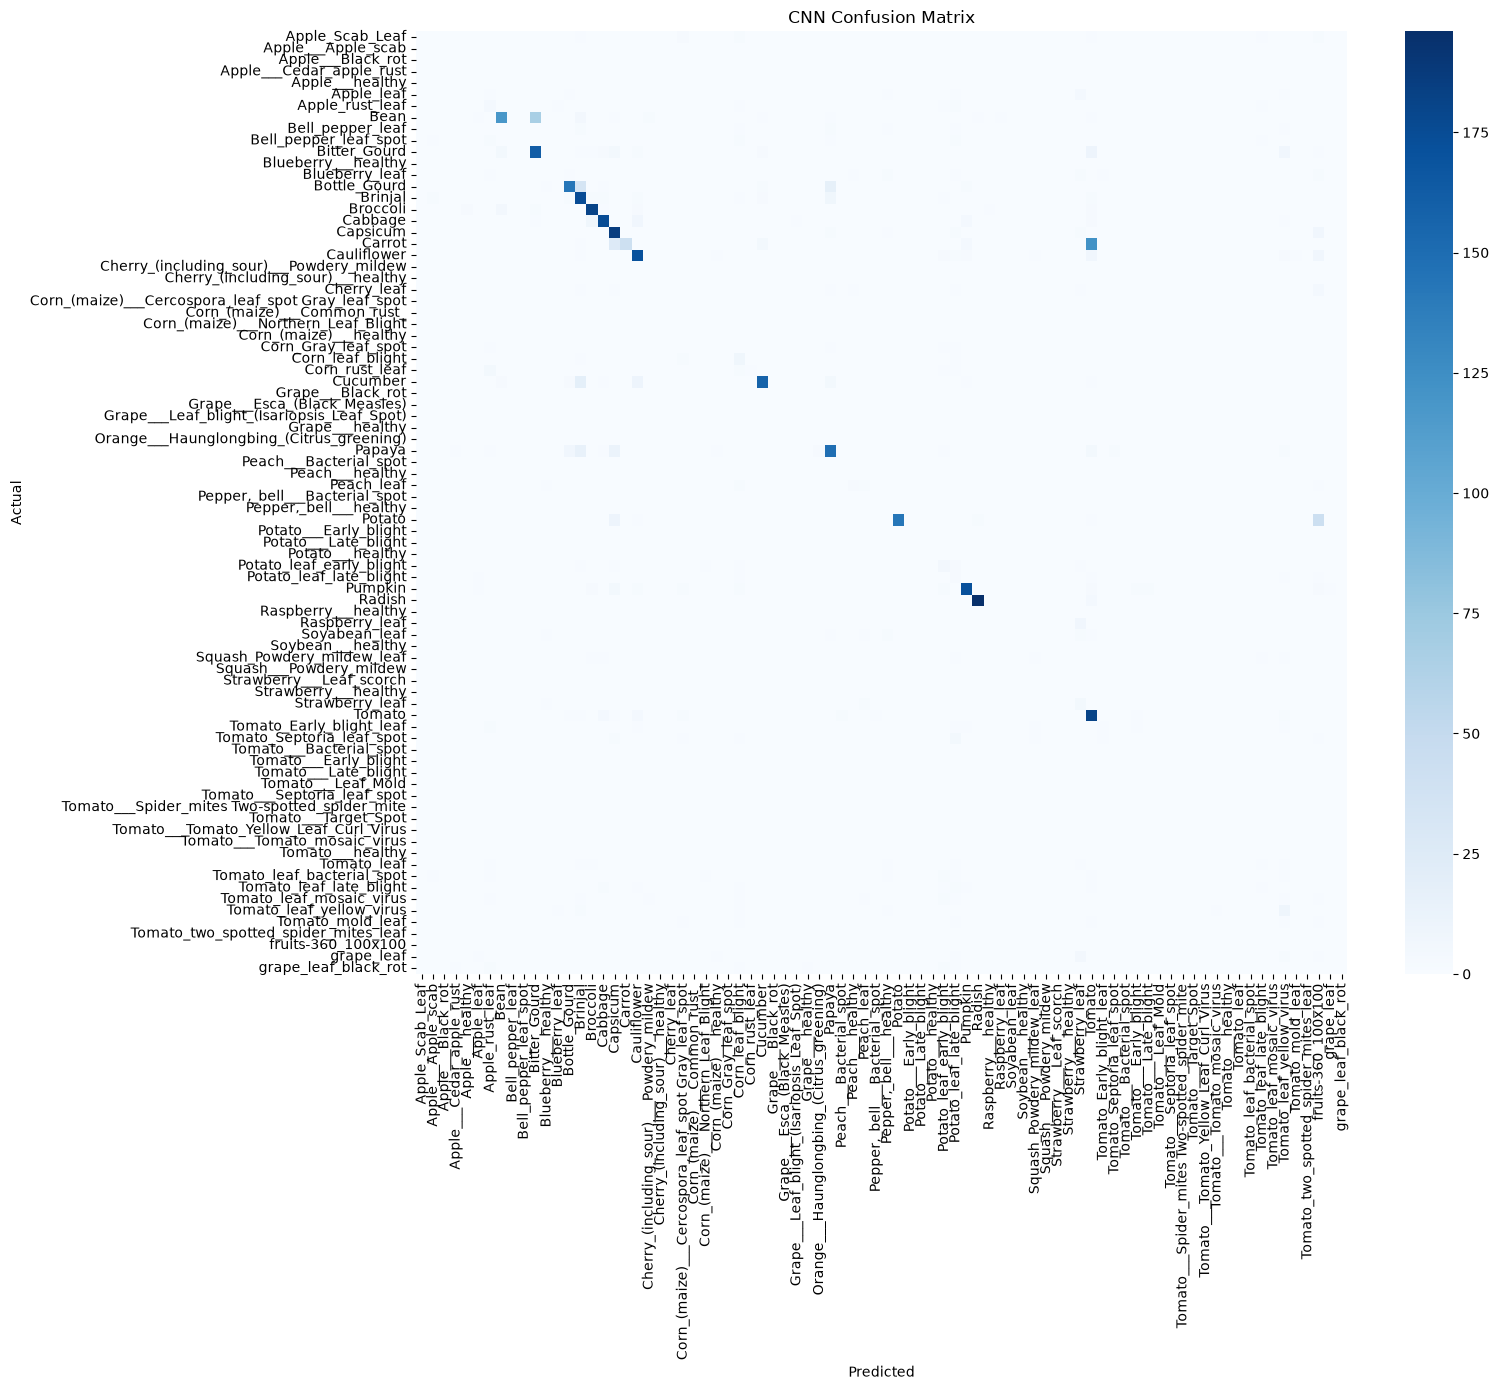

In [9]:
if cnn_results is not None:
    cm = confusion_matrix(
        cnn_results["Actual_Index"],
        cnn_results["Predicted_Class"].map(label_to_idx),
        labels=list(range(NUM_CLASSES))
    )
    np.save(OUTPUT_ROOT / "cnn_confusion_matrix.npy", cm)

    plt.figure(figsize=(16,14))
    sns.heatmap(cm, cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.title("CNN Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.savefig(OUTPUT_ROOT / "cnn_confusion_matrix.png", dpi=200)
    plt.show()

## CNN correct/incorrect summary

In [10]:
if cnn_results is not None:
    summary = pd.DataFrame([{
        "Test_Images": len(cnn_results),
        "Correct": int(cnn_results["Correct"].sum()),
        "Incorrect": int((~cnn_results["Correct"]).sum()),
        "Accuracy": cnn_metrics["accuracy"],
        "Mean_Confidence": float(cnn_results["Confidence"].mean())
    }])
    display(summary)

,Test_Images,Correct,Incorrect,Accuracy,Mean_Confidence
0,3252,2392,860,0.735547,0.744673


## CNN class-wise performance

In [11]:
if cnn_results is not None:
    y_t = cnn_results["Actual_Index"].to_numpy()
    y_p = cnn_results["Predicted_Class"].map(label_to_idx).to_numpy()
    report = classification_report(
        y_t, y_p, labels=list(range(NUM_CLASSES)),
        target_names=class_names, output_dict=True, zero_division=0
    )
    class_perf = pd.DataFrame(report).T.loc[class_names, ["precision","recall","f1-score","support"]]
    class_perf = class_perf.sort_values("f1-score")
    display(class_perf.head(10))
    display(class_perf.tail(10))
    class_perf.to_csv(OUTPUT_ROOT / "cnn_classwise_performance.csv")

,precision,recall,f1-score,support
Apple_Scab_Leaf,0.0,0.0,0.0,10.0
Apple___Apple_scab,0.0,0.0,0.0,0.0
Apple___Black_rot,0.0,0.0,0.0,0.0
Apple___Cedar_apple_rust,0.0,0.0,0.0,0.0
Apple___healthy,0.0,0.0,0.0,0.0
Apple_leaf,0.0,0.0,0.0,9.0
Bell_pepper_leaf_spot,0.0,0.0,0.0,9.0
Bell_pepper_leaf,0.0,0.0,0.0,8.0
Blueberry___healthy,0.0,0.0,0.0,0.0
Blueberry_leaf,0.0,0.0,0.0,11.0


,precision,recall,f1-score,support
Papaya,0.792553,0.745,0.768041,200.0
Bottle_Gourd,0.905063,0.715,0.798883,200.0
Capsicum,0.744000,0.930,0.826667,200.0
Potato,1.000000,0.715,0.833819,200.0
Cucumber,0.918129,0.785,0.846361,200.0
Cauliflower,0.838235,0.855,0.846535,200.0
Pumpkin,0.914894,0.860,0.886598,200.0
Cabbage,0.916230,0.875,0.895141,200.0
Broccoli,0.918782,0.905,0.911839,200.0
Radish,0.984925,0.980,0.982456,200.0


## CNN confidence analysis

count    3252.000000
mean        0.744673
std         0.274751
min         0.060133
25%         0.535090
50%         0.859777
75%         0.988663
max         1.000000
Name: Confidence, dtype: float64


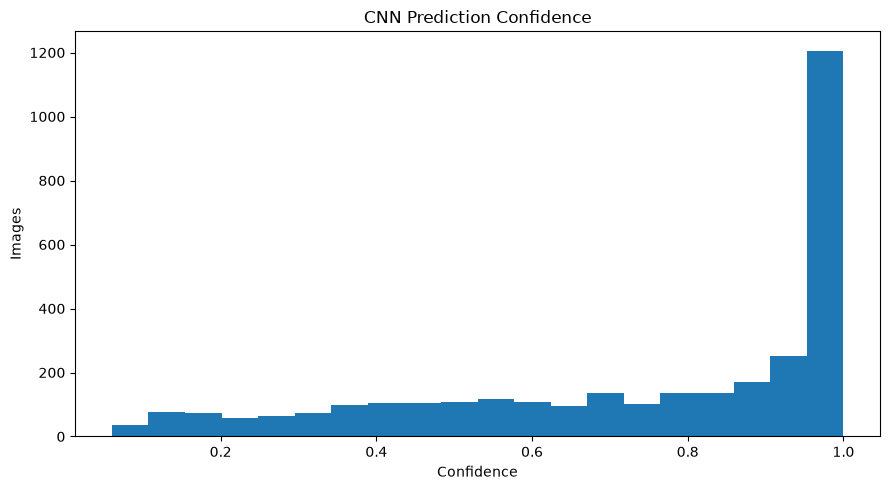

In [12]:
if cnn_results is not None:
    print(cnn_results["Confidence"].describe())
    plt.figure(figsize=(9,5))
    plt.hist(cnn_results["Confidence"], bins=20)
    plt.title("CNN Prediction Confidence")
    plt.xlabel("Confidence")
    plt.ylabel("Images")
    plt.tight_layout()
    plt.savefig(OUTPUT_ROOT / "cnn_confidence_distribution.png", dpi=200)
    plt.show()

## CNN sample predictions

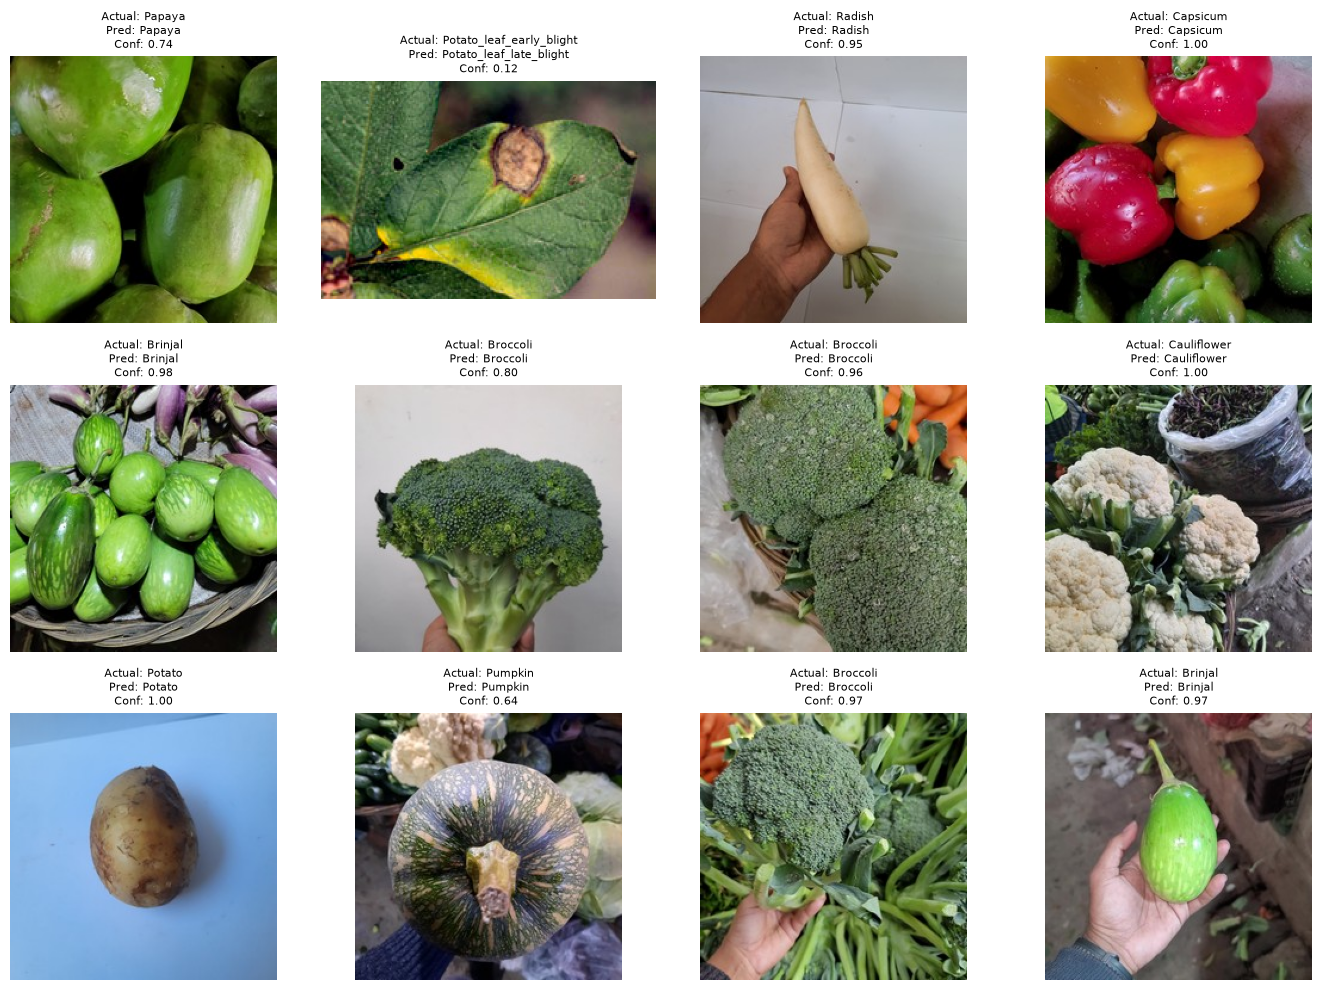

In [13]:
if cnn_results is not None:
    sample = cnn_results.sample(min(12, len(cnn_results)), random_state=RANDOM_SEED)
    fig, axes = plt.subplots(3,4, figsize=(14,10))
    axes = axes.ravel()
    for ax, (_, row) in zip(axes, sample.iterrows()):
        img = Image.open(row["Resolved_Image_Path"]).convert("RGB")
        ax.imshow(img)
        title = f"Actual: {row['Class']}\nPred: {row['Predicted_Class']}\nConf: {row['Confidence']:.2f}"
        ax.set_title(title, fontsize=8)
        ax.axis("off")
    for ax in axes[len(sample):]:
        ax.axis("off")
    plt.tight_layout()
    plt.savefig(OUTPUT_ROOT / "cnn_sample_predictions.png", dpi=200)
    plt.show()

## CNN incorrect predictions

In [14]:
if cnn_results is not None:
    incorrect = cnn_results[~cnn_results["Correct"]].sort_values("Confidence", ascending=False)
    display(incorrect.head(20))
    incorrect.to_csv(OUTPUT_ROOT / "cnn_incorrect_predictions.csv", index=False)

,Class,Filename,Resolved_Image_Path,Actual_Index,Predicted_Class,Confidence,Correct
275988,Potato,1092.jpg,Cleaned_Dataset\Vegetable Dataset\test\Potato\...,42,fruits-360_100x100,1.000000,False
275936,Potato,1040.jpg,Cleaned_Dataset\Vegetable Dataset\test\Potato\...,42,fruits-360_100x100,1.000000,False
276022,Potato,1126.jpg,Cleaned_Dataset\Vegetable Dataset\test\Potato\...,42,fruits-360_100x100,1.000000,False
275991,Potato,1095.jpg,Cleaned_Dataset\Vegetable Dataset\test\Potato\...,42,fruits-360_100x100,1.000000,False
275986,Potato,1090.jpg,Cleaned_Dataset\Vegetable Dataset\test\Potato\...,42,fruits-360_100x100,1.000000,False
275924,Potato,1027.jpg,Cleaned_Dataset\Vegetable Dataset\test\Potato\...,42,fruits-360_100x100,1.000000,False
275974,Potato,1078.jpg,Cleaned_Dataset\Vegetable Dataset\test\Potato\...,42,fruits-360_100x100,1.000000,False
275957,Potato,1061.jpg,Cleaned_Dataset\Vegetable Dataset\test\Potato\...,42,fruits-360_100x100,1.000000,False
276068,Potato,1172.jpg,Cleaned_Dataset\Vegetable Dataset\test\Potato\...,42,fruits-360_100x100,0.999999,False
275983,Potato,1087.jpg,Cleaned_Dataset\Vegetable Dataset\test\Potato\...,42,fruits-360_100x100,0.999999,False


## Locate and load YOLO11 classification model

In [15]:
try:
    from ultralytics import YOLO
except Exception:
    YOLO = None

yolo_model = None
if YOLO_BEST.exists() and YOLO is not None:
    try:
        yolo_model = YOLO(str(YOLO_BEST))
        print("YOLO MODEL LOADED")
        print("Path:", YOLO_BEST)
        print("Task:", getattr(yolo_model, "task", "unknown"))
    except Exception as e:
        print("YOLO load failed:", e)
else:
    print("YOLO model unavailable.")

YOLO MODEL LOADED
Path: E:\programming languages\DJANGO PROJECT\SmartAgriVision\SmartAgriVision\AgriVision\AI\notebooks\YOLO_Models\classification_runs\smartagrivision_yolo_classification_cpu\weights\best.pt
Task: classify


## YOLO classification final test

In [16]:
yolo_results = None
if yolo_model is None:
    print("YOLO final testing skipped safely.")
else:
    yolo_rows = []
    for _, row in test_meta[test_meta["Resolved_Image_Path"].notna()].iterrows():
        try:
            result = yolo_model.predict(
                source=str(row["Resolved_Image_Path"]),
                imgsz=224,
                device="cpu",
                verbose=False
            )[0]
            probs_obj = getattr(result, "probs", None)
            if probs_obj is None:
                continue

            top1 = int(probs_obj.top1)
            conf = float(probs_obj.top1conf)
            names = result.names
            pred_name = names[top1] if isinstance(names, dict) else str(top1)

            yolo_rows.append({
                "Filename": row["Filename"],
                "Actual_Class": row["Class"],
                "Predicted_Class": pred_name,
                "Confidence": conf,
                "Correct": str(row["Class"]) == str(pred_name),
                "Image_Path": str(row["Resolved_Image_Path"])
            })
        except Exception as e:
            yolo_rows.append({
                "Filename": row["Filename"],
                "Actual_Class": row["Class"],
                "Predicted_Class": None,
                "Confidence": np.nan,
                "Correct": False,
                "Image_Path": str(row["Resolved_Image_Path"]),
                "Error": str(e)
            })

    yolo_results = pd.DataFrame(yolo_rows)
    display(yolo_results.head())
    yolo_results.to_csv(OUTPUT_ROOT / "yolo_classification_predictions.csv", index=False)

,Filename,Actual_Class,Predicted_Class,Confidence,Correct,Image_Path
0,test_Apple leaf_1.jpg,Apple_leaf,Apple_leaf,0.404474,True,Cleaned_Dataset\PlantDoc\test\Apple_leaf\test_...
1,test_Apple leaf_2.jpg,Apple_leaf,Apple_leaf,0.537095,True,Cleaned_Dataset\PlantDoc\test\Apple_leaf\test_...
2,test_Apple leaf_3.jpg,Apple_leaf,Potato_leaf_late_blight,0.125776,False,Cleaned_Dataset\PlantDoc\test\Apple_leaf\test_...
3,test_Apple leaf_4.jpg,Apple_leaf,Apple_leaf,0.489698,True,Cleaned_Dataset\PlantDoc\test\Apple_leaf\test_...
4,test_Apple leaf_5.jpg,Apple_leaf,Apple_leaf,0.503509,True,Cleaned_Dataset\PlantDoc\test\Apple_leaf\test_...


## YOLO classification metrics

In [17]:
if yolo_results is not None and len(yolo_results):
    valid_y = yolo_results.dropna(subset=["Predicted_Class"]).copy()
    yt = valid_y["Actual_Class"]
    yp = valid_y["Predicted_Class"]

    yolo_metrics = {
        "accuracy": float(accuracy_score(yt, yp)),
        "precision_macro": float(precision_score(yt, yp, average="macro", zero_division=0)),
        "recall_macro": float(recall_score(yt, yp, average="macro", zero_division=0)),
        "f1_macro": float(f1_score(yt, yp, average="macro", zero_division=0)),
    }

    print("YOLO CLASSIFICATION METRICS")
    for k,v in yolo_metrics.items():
        print(f"{k}: {v:.4f}")

    yolo_report = pd.DataFrame(
        classification_report(yt, yp, output_dict=True, zero_division=0)
    ).T
    yolo_report.to_csv(OUTPUT_ROOT / "yolo_classification_report.csv")
else:
    yolo_metrics = None

YOLO CLASSIFICATION METRICS
accuracy: 0.9385
precision_macro: 0.4244
recall_macro: 0.3848
f1_macro: 0.3849


## CNN vs YOLO classification comparison

In [18]:
comparison_rows = []

if cnn_results is not None:
    comparison_rows.append({
        "Model": "CNN",
        "Accuracy": cnn_metrics["accuracy"],
        "Precision_Macro": cnn_metrics["precision_macro"],
        "Recall_Macro": cnn_metrics["recall_macro"],
        "F1_Macro": cnn_metrics["f1_macro"]
    })

if yolo_metrics is not None:
    comparison_rows.append({
        "Model": "YOLO11n-Classification",
        "Accuracy": yolo_metrics["accuracy"],
        "Precision_Macro": yolo_metrics["precision_macro"],
        "Recall_Macro": yolo_metrics["recall_macro"],
        "F1_Macro": yolo_metrics["f1_macro"]
    })

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)

if len(comparison_df):
    comparison_df.to_csv(OUTPUT_ROOT / "model_comparison.csv", index=False)

,Model,Accuracy,Precision_Macro,Recall_Macro,F1_Macro
0,CNN,0.735547,0.258269,0.250810,0.233502
1,YOLO11n-Classification,0.938499,0.424432,0.384796,0.384890


## Save final testing outputs

In [19]:
status = {
    "metadata_rows": int(len(metadata)),
    "classes": int(NUM_CLASSES),
    "test_metadata_records": int(len(test_meta)),
    "test_resolved_images": int(resolved),
    "cnn_model_available": cnn_model is not None,
    "yolo_model_available": yolo_model is not None,
    "cnn_metrics": cnn_metrics if cnn_results is not None else None,
    "yolo_metrics": yolo_metrics,
    "output_directory": str(OUTPUT_ROOT),
}

with open(OUTPUT_ROOT / "final_testing_status.json", "w", encoding="utf-8") as f:
    json.dump(status, f, indent=2)

if cnn_results is not None:
    cnn_results.to_csv(OUTPUT_ROOT / "cnn_final_test_predictions.csv", index=False)

print("FINAL TESTING OUTPUTS SAVED")
print(OUTPUT_ROOT)

FINAL TESTING OUTPUTS SAVED
E:\programming languages\DJANGO PROJECT\SmartAgriVision\SmartAgriVision\AgriVision\AI\notebooks\Final_Testing_Results


## Final testing status

In [20]:
print("=" * 60)
print("FINAL TESTING STATUS")
print("=" * 60)
print("Metadata available:", METADATA_PATH.exists())
print("Classes:", NUM_CLASSES)
print("Test records:", len(test_meta))
print("Resolved test images:", resolved)
print("CNN model available:", cnn_model is not None)
print("YOLO model available:", yolo_model is not None)
print("CNN evaluation completed:", cnn_results is not None)
print("YOLO evaluation completed:", yolo_results is not None and len(yolo_results) > 0)
print("Output:", OUTPUT_ROOT)

if cnn_results is not None:
    print(f"CNN accuracy: {cnn_metrics['accuracy']:.4f}")
    print(f"CNN precision: {cnn_metrics['precision_macro']:.4f}")
    print(f"CNN recall: {cnn_metrics['recall_macro']:.4f}")
    print(f"CNN F1: {cnn_metrics['f1_macro']:.4f}")

if yolo_metrics is not None:
    print(f"YOLO accuracy: {yolo_metrics['accuracy']:.4f}")
    print(f"YOLO precision: {yolo_metrics['precision_macro']:.4f}")
    print(f"YOLO recall: {yolo_metrics['recall_macro']:.4f}")
    print(f"YOLO F1: {yolo_metrics['f1_macro']:.4f}")

print("=" * 60)
print("FINAL TESTING COMPLETED SAFELY")
print("=" * 60)

FINAL TESTING STATUS
Metadata available: True
Classes: 82
Test records: 3252
Resolved test images: 3252
CNN model available: True
YOLO model available: True
CNN evaluation completed: True
YOLO evaluation completed: True
Output: E:\programming languages\DJANGO PROJECT\SmartAgriVision\SmartAgriVision\AgriVision\AI\notebooks\Final_Testing_Results
CNN accuracy: 0.7355
CNN precision: 0.2583
CNN recall: 0.2508
CNN F1: 0.2335
YOLO accuracy: 0.9385
YOLO precision: 0.4244
YOLO recall: 0.3848
YOLO F1: 0.3849
FINAL TESTING COMPLETED SAFELY
